In [12]:
import pandas as pd
import matplotlib.pyplot as plt

communes_2022 = pd.read_csv("../data/processed/communes_2022.csv")
display(communes_2022.shape)
display(communes_2022.head())
communes_2022.isna().sum()

(2115, 23)

,code,name,population,foreigners,foreign_share,share_under20,share_65plus,density,canton,major_region,...,sa_rate,jobs_primary,jobs_secondary,jobs_tertiary,jobs_total,tax_normal,tax_special,tax_total,tax_per_capita,jobs_per_capita
0,1,Aeugst am Albis,1991,294.0,14.8,18.8,20.4,251.7,ZH,Zurich,...,0.9,42.0,18.0,410.0,470.0,4821708.65,902644.05,5724352.70,2875.114365,0.236062
1,10,Obfelden,5787,1242.0,21.5,23.5,17.5,767.5,ZH,Zurich,...,2.4,53.0,284.0,1129.0,1466.0,5790084.95,591236.30,6381321.25,1102.699369,0.253326
2,100,Stadel,2349,317.0,13.5,20.1,17.8,182.2,ZH,Zurich,...,1.3,92.0,63.0,404.0,559.0,2289562.55,172083.85,2461646.40,1047.955045,0.237974
3,1001,Doppleschwand,806,34.0,4.2,24.3,15.8,116.0,LU,Central CH,...,NaN,76.0,49.0,94.0,219.0,362504.40,5514.00,368018.40,456.598511,0.271712
4,1002,Entlebuch,3267,231.0,7.1,21.2,19.0,57.4,LU,Central CH,...,0.8,385.0,481.0,1045.0,1911.0,1466934.15,293908.15,1760842.30,538.978359,0.584940


code                 0
name                 0
population           0
foreigners           6
foreign_share        6
share_under20        2
share_65plus         0
density              0
canton               1
major_region         1
urban_rural          1
language             1
sa_recipients      487
sa_rate            487
jobs_primary        50
jobs_secondary      67
jobs_tertiary       14
jobs_total           3
tax_normal          10
tax_special         10
tax_total           10
tax_per_capita      10
jobs_per_capita      3
dtype: int64

# Terminology clarification

- **Commune**: one row of the table; Swiss communes on the 2025 list (2,115). Data refer to 2022.
- **Population**: permanent resident population of the commune.
- **Foreigners**: permanent residents without Swiss citizenship.
- **Foreign share**: foreigners ÷ population, in %.
- **Share under 20 / share 65+**: % of residents in each age group.
- **Density**: residents per km² of total commune area.

**Outcomes**
- **Tax per resident**: federal income tax only (not cantonal or communal), per year, divided by all residents, including children and people who pay nothing.
  - *Normal cases*: taxpayers taxed normally for the full year.
  - *Special cases*: e.g. people who moved in or out during the year, or are only partly taxable in Switzerland.
- **Social assistance rate**: % of residents who receive social assistance (last-resort cash support), not an amount of money.
- **Social assistance recipients**: number of people receiving it.

**Economy**
- **Jobs**: jobs located in the commune (where people work, not where they live).
  - *Primary*: agriculture, forestry. *Secondary*: industry, construction. *Tertiary*: services.
- **Jobs per resident**: jobs ÷ population; above 1 means a job centre that attracts commuters.

**Classifications (SFSO, 2020)**
- **Canton**: one of 26.
- **Major region**: 7 large regions (e.g. Lake Geneva, Zurich).
- **Urban / intermediate / rural**: SFSO urban–rural typology.
- **Language region**: German, French, Italian or Romansh.

**Missing values**
- **NaN**: value not available, mostly hidden for privacy in small communes.

# Expectations before exploring the data

**1. Foreign share**
- Ordinary communes (not financial hubs, student towns or tourist areas): around 5%.
- Tourist communes: around 30%, because of foreign seasonal workers.
- Financial hubs and large cities (e.g. Geneva, Bern): around 40%.
- Student towns (e.g. Lausanne): around 50%.

**2. Federal tax per resident (per year)**
- My guess:  800 CHF.

**3. Social assistance rate**
- Around 20% of residents in a typical commune.

**4. Urban vs. rural**
- More foreigners in urban communes, with exceptions in tourist areas (e.g. Täsch, Zermatt) that employ many foreign workers.

**5. Language regions**
- More foreigners in regions close to the national borders. At first glance, I expect German-speaking communes to have the highest foreign share; worth checking which language region has the most border communes.

**6. Foreign share and tax per resident**
- I expect a positive association, because …

**7. Foreign share and social assistance rate**
- I expect a positive association, because …

In [15]:
# Descriptive stats before plotting
display(communes_2022["code"].duplicated().sum())
display(communes_2022.describe().T)
display(  communes_2022.describe().T.round(1))

np.int64(0)

,count,mean,std,min,25%,50%,75%,max
code,2115.0,3.284740e+03,2.133338e+03,1.000000,1065.500000,3.293000e+03,5.412500e+03,6.812000e+03
population,2115.0,4.168031e+03,1.322079e+04,29.000000,782.500000,1.701000e+03,4.104500e+03,4.277210e+05
foreigners,2109.0,1.088674e+03,4.700179e+03,0.000000,91.000000,2.600000e+02,8.220000e+02,1.409480e+05
foreign_share,2109.0,1.776961e+01,9.775233e+00,0.000000,10.200000,1.620000e+01,2.410000e+01,6.050000e+01
share_under20,2113.0,2.034524e+01,3.261937e+00,3.200000,18.700000,2.050000e+01,2.230000e+01,3.330000e+01
share_65plus,2115.0,2.027981e+01,4.522661e+00,6.800000,17.300000,1.980000e+01,2.260000e+01,5.000000e+01
density,2115.0,4.547832e+02,8.169976e+02,0.800000,84.150000,1.942000e+02,4.901000e+02,1.277190e+04
sa_recipients,1628.0,1.607138e+02,7.365532e+02,6.000000,14.000000,3.200000e+01,1.032500e+02,1.725300e+04
sa_rate,1628.0,2.033968e+00,1.582474e+00,0.200000,1.000000,1.600000e+00,2.525000e+00,1.060000e+01
jobs_primary,2065.0,7.712107e+01,8.494647e+01,0.000000,25.000000,4.800000e+01,9.800000e+01,8.120000e+02


,count,mean,std,min,25%,50%,75%,max
code,2115.0,3284.7,2133.3,1.0,1065.5,3293.0,5412.5,6812.0
population,2115.0,4168.0,13220.8,29.0,782.5,1701.0,4104.5,427721.0
foreigners,2109.0,1088.7,4700.2,0.0,91.0,260.0,822.0,140948.0
foreign_share,2109.0,17.8,9.8,0.0,10.2,16.2,24.1,60.5
share_under20,2113.0,20.3,3.3,3.2,18.7,20.5,22.3,33.3
share_65plus,2115.0,20.3,4.5,6.8,17.3,19.8,22.6,50.0
density,2115.0,454.8,817.0,0.8,84.2,194.2,490.1,12771.9
sa_recipients,1628.0,160.7,736.6,6.0,14.0,32.0,103.2,17253.0
sa_rate,1628.0,2.0,1.6,0.2,1.0,1.6,2.5,10.6
jobs_primary,2065.0,77.1,84.9,0.0,25.0,48.0,98.0,812.0


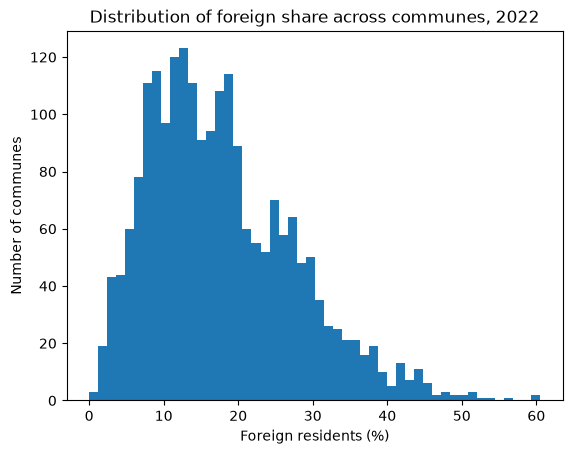

In [16]:
plt.hist(communes_2022["foreign_share"].dropna(), bins=50)
plt.xlabel("Foreign residents (%)")
plt.ylabel("Number of communes")
plt.title("Distribution of foreign share across communes, 2022")
plt.show()